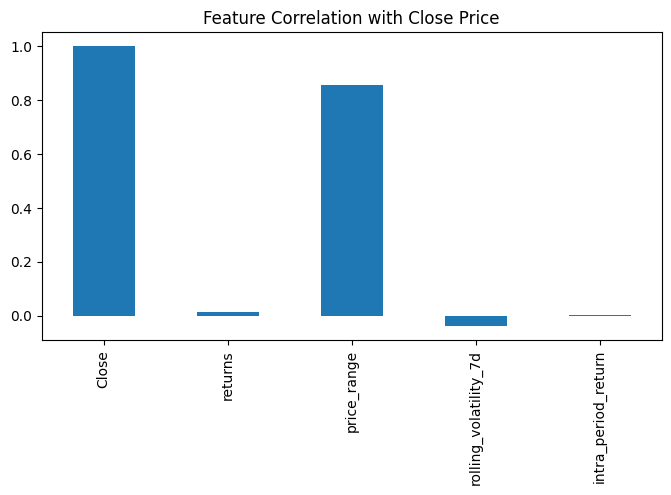

,Open,Close,High,Low,returns,price_range,rolling_volatility_7d,intra_period_return
Date,,,,,,,,
1999-02-02 00:00:00-05:00,0.036295,0.034147,0.037251,0.033072,-0.077419,0.004178,0.064042,-0.059192
1999-02-03 00:00:00-05:00,0.033669,0.034863,0.035341,0.033430,0.020972,0.001911,0.042942,0.035458
1999-02-04 00:00:00-05:00,0.035341,0.036773,0.037728,0.034863,0.054786,0.002865,0.044495,0.040527
1999-02-05 00:00:00-05:00,0.037370,0.037847,0.038206,0.036415,0.029224,0.001791,0.046366,0.012784
1999-02-08 00:00:00-05:00,0.038086,0.036534,0.038206,0.036534,-0.034693,0.001672,0.048175,-0.040736


In [24]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Load NVDA historical data
# -----------------------------
ticker_data = yf.Ticker('NVDA').history(period='max')
ticker_data = ticker_data[['Open', 'Close', 'High', 'Low']]

# -----------------------------
# Feature 1: Daily Return (%)
# -----------------------------
ticker_data['returns'] = ticker_data['Close'].pct_change()
# Rationale: Daily returns help analyze short-term volatility and performance.

# -----------------------------
# Feature 2: Price Range (High - Low)
# -----------------------------
ticker_data['price_range'] = ticker_data['High'] - ticker_data['Low']
# Rationale: Captures intraday volatility, indicating market activity intensity.

# -----------------------------
# Feature 3: Rolling 7-day Return Volatility
# -----------------------------
ticker_data['rolling_volatility_7d'] = ticker_data['returns'].rolling(window=7).std()
# Rationale: Helps detect periods of unusual volatility, useful for risk modeling.

# -----------------------------
# Feature 4: Intra-period Return (Close-Open %)
# -----------------------------
ticker_data['intra_period_return'] = (ticker_data['Close'] - ticker_data['Open']) / ticker_data['Open']
# Rationale: Shows intraday strength or weakness relative to the opening price.

# -----------------------------
# Drop rows with NaNs from rolling calculations
# -----------------------------
ticker_data = ticker_data.dropna()

# -----------------------------
# Correlation Check
# -----------------------------
correlation = ticker_data.drop(columns=['High', 'Low', 'Open']).corrwith(ticker_data['Close'])
correlation.plot(kind='bar', figsize=(8, 4), title='Feature Correlation with Close Price')
plt.show()

ticker_data.head()

## Feature 1: Daily Return (`returns`)
- **Reasoning:** Measures the percentage change in closing price compared to the previous day.
- **Usefulness:** Captures daily market movement and is a key metric for volatility and performance analysis.

---

## Feature 2: Price Range (`price_range`)
- **Reasoning:** Difference between the day’s high and low price.
- **Usefulness:** Indicates intraday volatility and market sentiment strength.

---

## Feature 3: Rolling 7-day Volatility (`rolling_volatility_7d`)
- **Reasoning:** 7-day rolling standard deviation of daily returns.
- **Usefulness:** Helps detect market instability and trend reversals, valuable for risk models.

---

## Feature 4: Intra-Period Return (`intra_period_return`)
- **Reasoning:** Percentage change from the opening to closing price within the same day.
- **Usefulness:** Highlights intraday strength or weakness, useful for short-term strategy building.